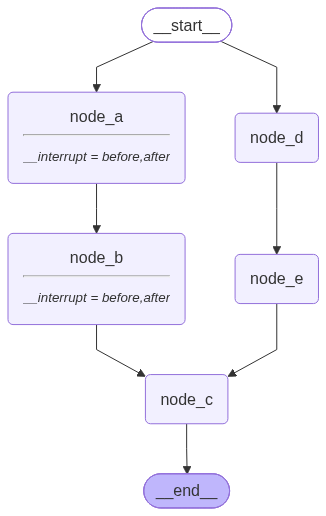

In [13]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from loguru import logger
from typing import TypedDict

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a is running....")
    return {
        "final_res": "node_a running middle result."
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b is running....")
    return {
        "final_res": "node_b running middle result."
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c is running....")
    return {
        "final_res": "node_c running middle result."
    }

def node_d(state: OverAllState) -> OverAllState:
    logger.info("node_d is running....")
    return {
        # "final_res": "node_d running middle result."
    }

def node_e(state: OverAllState) -> OverAllState:
    logger.info("node_e is running....")
    return {
        # "final_res": "node_e running middle result."
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_e", node_e)
builder.add_node("node_d", node_d)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge(START, "node_d")

builder.add_edge("node_b", "node_c")
builder.add_edge("node_d", "node_e")
builder.add_edge("node_e", "node_c")
builder.add_edge("node_c", END)


checkpointer = InMemorySaver()
graph=builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"],
)


from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "333"}}


In [14]:
logger.info("*"*50, "The 1st time", "*"*50)
first_res = graph.invoke({},config=config)
print(first_res)

2026-09-01 21:10:08.517 | INFO     | __main__:<module>:1 - **************************************************


None


In [15]:
logger.info("*"*50, "The 2nd time", "*"*50)
second_res = graph.invoke(None,config=config)
print(second_res)

2026-09-01 21:10:08.569 | INFO     | __main__:<module>:1 - **************************************************
2026-09-01 21:10:08.572 | INFO     | __main__:node_a:10 - node_a is running....
2026-09-01 21:10:08.575 | INFO     | __main__:node_d:28 - node_d is running....


{'final_res': 'node_a running middle result.'}


In [16]:
logger.info("*"*50, "The 3rd time", "*"*50)
third_res = graph.invoke(None,config=config)
print(third_res)

2026-09-01 21:11:03.884 | INFO     | __main__:<module>:1 - **************************************************
2026-09-01 21:11:03.888 | INFO     | __main__:node_b:16 - node_b is running....
2026-09-01 21:11:03.895 | INFO     | __main__:node_e:34 - node_e is running....


{'final_res': 'node_b running middle result.'}


In [17]:
logger.info("*"*50, "The 4th time", "*"*50)
forth_res = graph.invoke(None,config=config)
print(forth_res)

2026-09-01 21:11:23.750 | INFO     | __main__:<module>:1 - **************************************************
2026-09-01 21:11:23.752 | INFO     | __main__:node_c:22 - node_c is running....


{'final_res': 'node_c running middle result.'}
